# Segundo modelo de aprendizaje no supervisado: DBSCAN
**Segmentación comercial de ventas de una cafetería-restaurante** · Sistemas Inteligentes · UNC

Este cuaderno continúa el trabajo del primer modelo (K-means, k = 6). Parte del dataset limpio que dejó
el primer cuaderno (`ventas_cafeteria_limpio.csv`, 1 486 boletas) y:

1. Entrena **DBSCAN** con las mismas cuatro variables escaladas que K-means, para que la comparación sea justa.
2. Elige `min_samples` y `eps` con el gráfico de k-distancias y una búsqueda en grilla.
3. Evalúa el modelo y describe sus grupos y su ruido.
4. **Compara** DBSCAN con K-means (métricas, tabla cruzada, ARI y asignación de ventas nuevas).
5. Verifica que el modelo elegido (**K-means**) coincide con la API desplegada.

## 1. Librerías y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
# En Colab: subir ventas_cafeteria_limpio.csv (generado por el cuaderno del primer modelo)
df = pd.read_csv("ventas_cafeteria_limpio.csv")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 1486 | Columnas: 14


,ID_Ticket,Fecha,Dia_Semana,Hora_Dia,Monto_Total,Cantidad_Items,Para_Llevar,Tiempo_Permanencia_Min,Es_FinDeSemana,Pago_Efectivo,Pago_Plin,Pago_Tarjeta,Pago_Yape,Cluster
0,T0001,2026-06-01,1,9,16.500,3,1,2.000,0,0,0,1,0,4
1,T0002,2026-06-01,1,10,13.300,2,0,11.000,0,1,0,0,0,4
2,T0003,2026-06-01,1,12,14.000,1,0,32.000,0,0,1,0,0,4
3,T0004,2026-06-01,1,12,36.900,4,0,13.000,0,0,1,0,0,1
4,T0005,2026-06-01,1,12,9.400,2,0,15.000,0,0,0,0,1,4


## 2. Mismas variables y mismo escalado que K-means
Para comparar los dos modelos de forma justa se usan exactamente las mismas cuatro variables
(`Monto_Total`, `Cantidad_Items`, `Hora_Dia`, `Es_FinDeSemana`) y el mismo `StandardScaler`.
También se vuelve a entrenar K-means con sus parámetros finales y se comprueba que reproduce la columna
`Cluster` del primer cuaderno.

In [3]:
FEATURES = ["Monto_Total", "Cantidad_Items", "Hora_Dia", "Es_FinDeSemana"]
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, init="k-means++", n_init=10, max_iter=300, random_state=42).fit(X_scaled)
assert (kmeans.labels_ == df["Cluster"].values).all(), "K-means no reproduce el primer modelo"
df = df.rename(columns={"Cluster": "Cluster_KMeans"})

NOMBRES_KM = {0: "Cena entre semana", 1: "Almuerzo entre semana", 2: "Cena fin de semana",
              3: "Tarde fin de semana", 4: "Desayuno entre semana", 5: "Tarde entre semana"}
print("K-means reproducido: inercia =", round(kmeans.inertia_, 1))

K-means reproducido: inercia = 711.2


## 3. Técnica elegida: DBSCAN
DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*; Ester et al., 1996) agrupa los
puntos que están en zonas densas y marca como **ruido** los que quedan aislados. Usa dos parámetros:

* `eps`: radio de la vecindad de cada punto.
* `min_samples`: puntos mínimos (incluido el propio punto) dentro de `eps` para que un punto sea **núcleo**.

Cada punto es **núcleo** (tiene al menos `min_samples` vecinos), **frontera** (está a menos de `eps` de un
núcleo, pero no es núcleo) o **ruido** (ninguna de las dos). Un clúster es un conjunto de núcleos
conectados por densidad junto con sus fronteras.

Se eligió como segundo modelo porque ataca justo las limitaciones de K-means: no exige fijar k,
no supone grupos esféricos ni de tamaño parecido y separa los atípicos como ruido en lugar de forzarlos
dentro de un clúster.

## 4. Elección de `min_samples`
La regla habitual es `min_samples ≥ D + 1`, y para datos con ruido se recomienda `min_samples ≈ 2·D`
(Sander et al., 1998; Schubert et al., 2017), donde D es el número de variables. Con D = 4 se toma
**`min_samples` = 8** como punto de partida y se prueban también 10, 12 y 15 en la grilla.

## 5. Elección de `eps`: gráfico de k-distancias
Para cada punto se calcula la distancia a su k-ésimo vecino más cercano (k = `min_samples`, contando el
propio punto), se ordenan de menor a mayor y se busca el **codo**: el punto donde la curva sube de golpe.
Las distancias a la izquierda del codo son típicas de zonas densas; a la derecha, de puntos aislados.
El codo se localiza como el punto de la curva más alejado de la recta que une sus extremos.

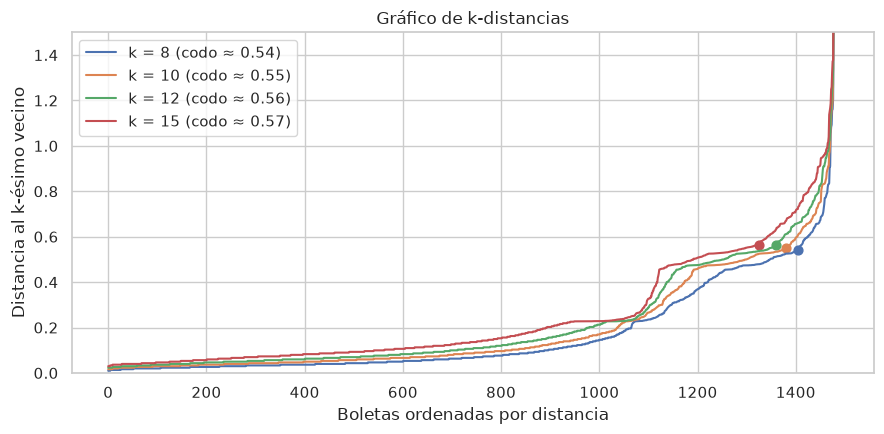

{8: np.float64(0.543), 10: np.float64(0.551), 12: np.float64(0.562), 15: np.float64(0.565)}
Percentiles de la 8-distancia: {50: np.float64(0.066), 80: np.float64(0.347), 90: np.float64(0.488), 95: np.float64(0.563), 99: np.float64(0.931)}


In [4]:
def k_distancias(X, k):
    # n_neighbors = k incluye al propio punto (distancia 0), igual que min_samples en DBSCAN
    dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
    return np.sort(dist[:, -1])

def codo(y):
    # punto de máxima distancia a la recta que une el primer y el último punto
    x = np.arange(len(y)); p1 = np.array([0, y[0]]); p2 = np.array([len(y) - 1, y[-1]])
    d = np.abs((p2[0] - p1[0]) * (p1[1] - y) - (p1[0] - x) * (p2[1] - p1[1])) / np.linalg.norm(p2 - p1)
    return int(np.argmax(d))

fig, ax = plt.subplots(figsize=(9, 4.5))
codos = {}
for k in [8, 10, 12, 15]:
    kd = k_distancias(X_scaled, k)
    i = codo(kd); codos[k] = kd[i]
    ax.plot(kd, label=f"k = {k} (codo ≈ {kd[i]:.2f})")
    ax.scatter(i, kd[i], s=40)
ax.set_xlabel("Boletas ordenadas por distancia"); ax.set_ylabel("Distancia al k-ésimo vecino")
ax.set_title("Gráfico de k-distancias"); ax.legend(); ax.set_ylim(0, 1.5)
plt.tight_layout(); plt.savefig("fig_kdistancias.png", dpi=150); plt.show()

kd8 = k_distancias(X_scaled, 8)
print({k: round(v, 3) for k, v in codos.items()})
print("Percentiles de la 8-distancia:", dict(zip([50, 80, 90, 95, 99], np.percentile(kd8, [50, 80, 90, 95, 99]).round(3))))

## 6. Búsqueda en grilla de `eps` y `min_samples`
Se prueban `eps` de 0.30 a 0.80 y `min_samples` de 8 a 15. Para cada combinación se calcula el número de
clústeres, el porcentaje de ruido y las métricas internas.

**Importante:** la silueta, Davies-Bouldin y Calinski-Harabasz se calculan **sin los puntos de ruido**
(no pertenecen a ningún clúster). Eso favorece a DBSCAN, porque descarta justo los puntos más difíciles;
por eso el porcentaje de ruido se reporta siempre al lado, y en la comparación final se incluye también
la silueta contando el ruido como un grupo más.

In [5]:
def evaluar(labels, X):
    m = labels != -1
    k = len(set(labels[m]))
    r = {"clusters": k, "ruido": int((~m).sum()), "ruido_%": 100 * (~m).mean()}
    if k >= 2:
        r.update({"silueta": silhouette_score(X[m], labels[m]),
                  "davies_bouldin": davies_bouldin_score(X[m], labels[m]),
                  "calinski_harabasz": calinski_harabasz_score(X[m], labels[m])})
    return r

filas = []
for ms in [8, 10, 12, 15]:
    for eps in np.round(np.arange(0.30, 0.81, 0.05), 2):
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        filas.append({"eps": eps, "min_samples": ms, **evaluar(lab, X_scaled)})
grid = pd.DataFrame(filas)
grid

,eps,min_samples,clusters,ruido,ruido_%,silueta,davies_bouldin,calinski_harabasz
0,0.300,8,20,257,17.295,0.473,0.790,2395.896
1,0.350,8,20,207,13.930,0.354,1.010,1409.127
2,0.400,8,22,165,11.104,0.349,1.040,1386.418
3,0.450,8,23,126,8.479,0.335,1.205,1418.482
4,0.500,8,6,61,4.105,0.514,0.636,965.785
5,0.550,8,4,35,2.355,0.554,0.715,1523.859
6,0.600,8,4,25,1.682,0.553,0.721,1538.268
7,0.650,8,4,18,1.211,0.551,0.731,1547.203
8,0.700,8,4,15,1.009,0.550,0.734,1550.279
9,0.750,8,4,15,1.009,0.550,0.734,1550.279


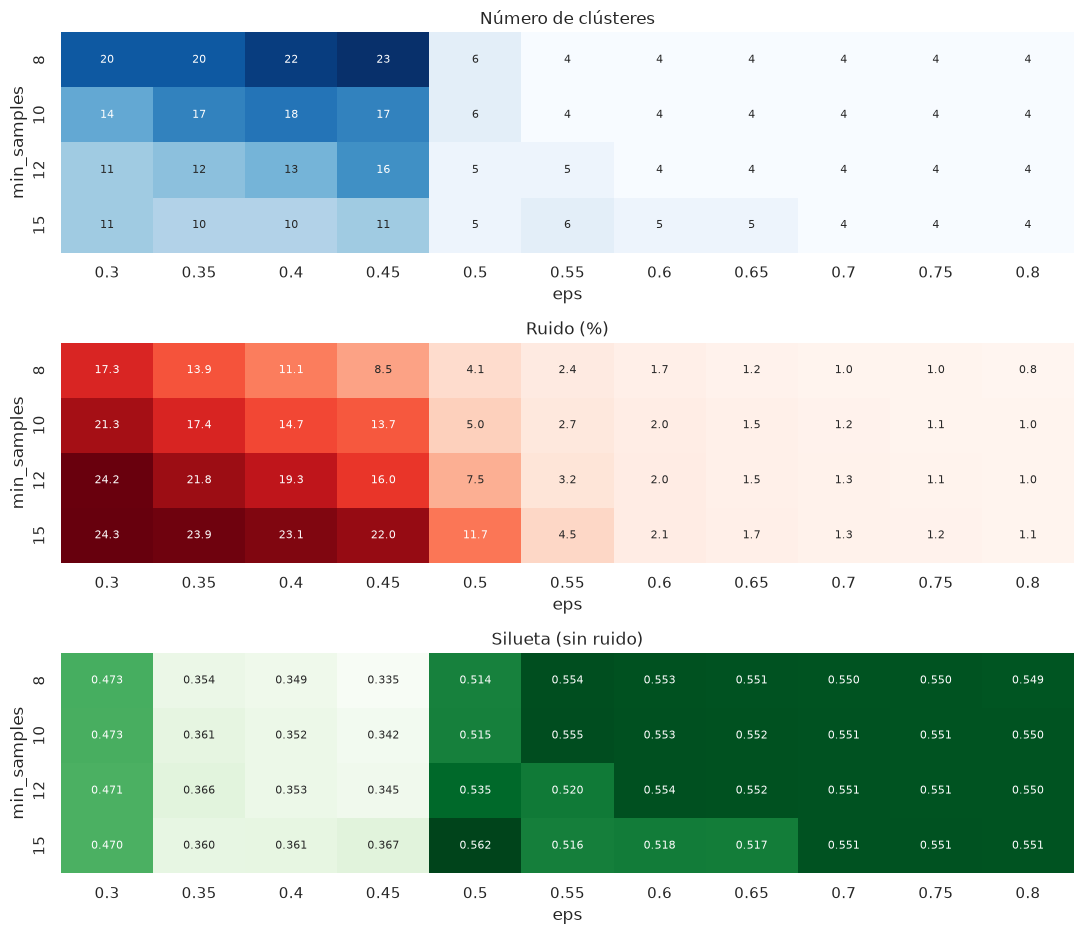

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9.5))
titulos = {"clusters": "Número de clústeres", "ruido_%": "Ruido (%)", "silueta": "Silueta (sin ruido)"}
for ax, col, fmt, cmap in zip(axes, ["clusters", "ruido_%", "silueta"], ["d", ".1f", ".3f"], ["Blues", "Reds", "Greens"]):
    t = grid.pivot(index="min_samples", columns="eps", values=col)
    sns.heatmap(t, annot=True, fmt=fmt, cmap=cmap, cbar=False, ax=ax, annot_kws={"size": 8})
    ax.set_title(titulos[col])
plt.tight_layout(); plt.savefig("fig_grilla_dbscan.png", dpi=150); plt.show()

### Criterio de selección
Se fijan reglas antes de elegir, para no escoger la combinación "a ojo":

1. **Ruido ≤ 10 %**: si DBSCAN descarta más, deja sin segmento a demasiadas ventas.
2. **Entre 3 y 10 clústeres**: menos es demasiado grueso para decisiones comerciales; más, inmanejable.
3. **`eps` cerca del codo** del gráfico de k-distancias (a no más de 0.10 del codo de su `min_samples`).
4. Entre las candidatas, se prefiere la de **menor Davies-Bouldin** (grupos compactos y separados) y,
   a igualdad, la de mayor silueta.

In [7]:
cerca_codo = (grid["eps"] - grid["min_samples"].map(codos)).abs() <= 0.10
cand = grid[(grid["ruido_%"] <= 10) & grid["clusters"].between(3, 10) & cerca_codo].copy()
cand = cand.sort_values(["davies_bouldin", "silueta"], ascending=[True, False])
cand.head(10)

,eps,min_samples,clusters,ruido,ruido_%,silueta,davies_bouldin,calinski_harabasz
26,0.500,12,5,112,7.537,0.535,0.589,1086.539
15,0.500,10,6,75,5.047,0.515,0.617,949.029
38,0.550,15,6,67,4.509,0.516,0.625,934.490
4,0.500,8,6,61,4.105,0.514,0.636,965.785
27,0.550,12,5,47,3.163,0.520,0.651,1174.901
39,0.600,15,5,31,2.086,0.518,0.660,1197.119
40,0.650,15,5,25,1.682,0.517,0.665,1209.833
16,0.550,10,4,40,2.692,0.555,0.710,1516.815
5,0.550,8,4,35,2.355,0.554,0.715,1523.859
28,0.600,12,4,30,2.019,0.554,0.716,1526.190


In [8]:
EPS, MIN_SAMPLES = float(cand.iloc[0]["eps"]), int(cand.iloc[0]["min_samples"])
print(f"Parámetros elegidos: eps = {EPS} | min_samples = {MIN_SAMPLES}")

Parámetros elegidos: eps = 0.5 | min_samples = 12


### Sensibilidad de la solución
DBSCAN es muy sensible a `eps`. Se compara la partición elegida con las que se obtienen moviendo `eps`
±0.05 y `min_samples` ±2, mediante el índice de Rand ajustado (ARI; Hubert y Arabie, 1985).

In [9]:
base = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
sens = []
for de in [-0.05, 0, 0.05]:
    for dm in [-2, 0, 2]:
        lab = DBSCAN(eps=round(EPS + de, 2), min_samples=MIN_SAMPLES + dm).fit_predict(X_scaled)
        e = evaluar(lab, X_scaled)
        sens.append({"eps": round(EPS + de, 2), "min_samples": MIN_SAMPLES + dm, "clusters": e["clusters"],
                     "ruido_%": e["ruido_%"], "ARI_vs_elegido": adjusted_rand_score(base, lab)})
pd.DataFrame(sens)

,eps,min_samples,clusters,ruido_%,ARI_vs_elegido
0,0.450,10,17,13.661,0.154
1,0.450,12,16,16.016,0.144
2,0.450,14,13,19.515,0.130
3,0.500,10,6,5.047,0.989
4,0.500,12,5,7.537,1.000
5,0.500,14,6,9.758,0.985
6,0.550,10,4,2.692,0.966
7,0.550,12,5,3.163,0.972
8,0.550,14,5,3.903,0.975


## 7. Entrenamiento del modelo final

In [10]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="euclidean")
dbscan.fit(X_scaled)
df["Cluster_DBSCAN"] = dbscan.labels_

nucleo = np.zeros(len(df), dtype=bool); nucleo[dbscan.core_sample_indices_] = True
df["Tipo_Punto"] = np.where(nucleo, "núcleo", np.where(dbscan.labels_ == -1, "ruido", "frontera"))
print(df["Tipo_Punto"].value_counts())
print()
print(df["Cluster_DBSCAN"].value_counts().sort_index().rename("boletas"))

Tipo_Punto
núcleo      1254
frontera     120
ruido        112
Name: count, dtype: int64

Cluster_DBSCAN
-1    112
 0    999
 1     84
 2    121
 3    148
 4     22
Name: boletas, dtype: int64


## 8. Evaluación de DBSCAN

In [11]:
lab = dbscan.labels_; m = lab != -1
met_db = evaluar(lab, X_scaled)
met_db["silueta_con_ruido"] = silhouette_score(X_scaled, lab)   # el ruido cuenta como un grupo más
pd.Series(met_db)

clusters               5.000
ruido                112.000
ruido_%                7.537
silueta                0.535
davies_bouldin         0.589
calinski_harabasz   1086.539
silueta_con_ruido      0.457
dtype: float64

In [12]:
# Silueta por clúster (sin ruido)
s = silhouette_samples(X_scaled[m], lab[m])
sil_cluster = pd.Series(s).groupby(lab[m]).mean().rename("silueta_media")
sil_cluster

0   0.516
1   0.639
2   0.646
3   0.507
4   0.599
Name: silueta_media, dtype: float64

### Perfiles de los clústeres de DBSCAN

In [13]:
perfil_db = df.groupby("Cluster_DBSCAN").agg(
    boletas=("ID_Ticket", "count"), monto=("Monto_Total", "mean"), items=("Cantidad_Items", "mean"),
    hora=("Hora_Dia", "mean"), hora_min=("Hora_Dia", "min"), hora_max=("Hora_Dia", "max"),
    fin_de_semana=("Es_FinDeSemana", "mean"), para_llevar=("Para_Llevar", "mean"),
    permanencia=("Tiempo_Permanencia_Min", "mean"))
perfil_db["%"] = 100 * perfil_db["boletas"] / len(df)
perfil_db

,boletas,monto,items,hora,hora_min,hora_max,fin_de_semana,para_llevar,permanencia,%
Cluster_DBSCAN,,,,,,,,,,
-1,112,71.249,5.438,17.170,7,22,0.500,0.179,49.750,7.537
0,999,20.129,2.209,12.454,7,22,0.000,0.277,23.461,67.227
1,84,80.956,7.071,20.571,19,22,0.000,0.048,67.238,5.653
2,121,11.227,1.537,16.612,13,20,1.000,0.182,23.554,8.143
3,148,84.684,6.074,20.399,19,22,1.000,0.061,63.770,9.960
4,22,35.205,3.091,13.409,12,15,1.000,0.364,27.000,1.480


In [14]:
# Composición horaria de cada clúster (útil para nombrarlos)
pd.crosstab(df["Cluster_DBSCAN"], pd.cut(df["Hora_Dia"], [6, 10, 14, 18, 22],
            labels=["7–10 h", "11–14 h", "15–18 h", "19–22 h"]), normalize="index").round(2)

Hora_Dia,7–10 h,11–14 h,15–18 h,19–22 h
Cluster_DBSCAN,,,,
-1,0.200,0.070,0.080,0.650
0,0.370,0.320,0.310,0.000
1,0.000,0.000,0.000,1.000
2,0.000,0.010,0.980,0.010
3,0.000,0.000,0.000,1.000
4,0.000,0.950,0.050,0.000


### Análisis del ruido
¿Qué boletas descarta DBSCAN como ruido y a qué clúster de K-means pertenecían?

In [15]:
ruido = df[df["Cluster_DBSCAN"] == -1]
print(ruido[["Monto_Total", "Cantidad_Items", "Hora_Dia", "Es_FinDeSemana", "Tiempo_Permanencia_Min"]].describe().round(2))
print()
print(ruido["Cluster_KMeans"].map(NOMBRES_KM).value_counts())

       Monto_Total  Cantidad_Items  Hora_Dia  Es_FinDeSemana  \
count      112.000         112.000   112.000         112.000   
mean        71.250           5.440    17.170           0.500   
std         43.710           2.640     4.980           0.500   
min          5.900           1.000     7.000           0.000   
25%         25.670           3.750    13.000           0.000   
50%         65.550           5.000    19.000           0.500   
75%        114.400           8.000    21.000           1.000   
max        150.000           9.000    22.000           1.000   

       Tiempo_Permanencia_Min  
count                 112.000  
mean                   49.750  
std                    29.220  
min                     2.000  
25%                    23.000  
50%                    55.000  
75%                    74.250  
max                   102.000  

Cluster_KMeans
Cena entre semana        45
Cena fin de semana       29
Tarde fin de semana      27
Almuerzo entre semana     8
Tarde e

## 9. Visualización

Varianza explicada: [0.63  0.206] | total: 0.836


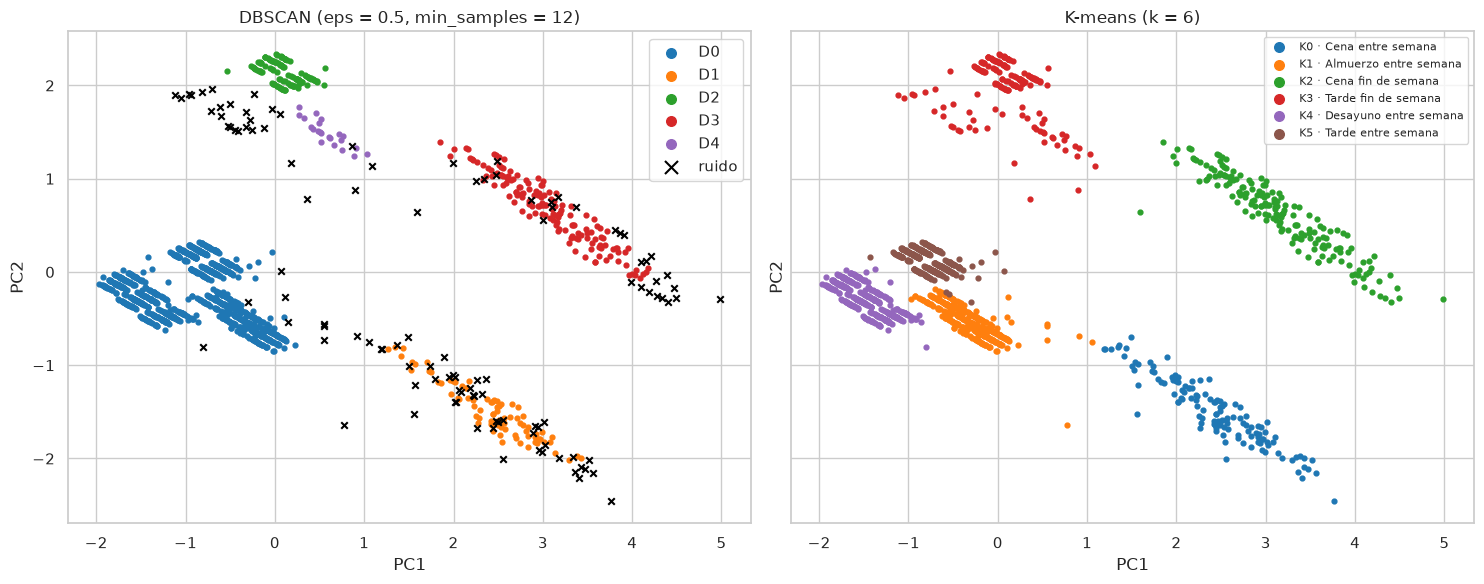

In [16]:
pca = PCA(n_components=2, random_state=42)
P = pca.fit_transform(X_scaled)
print("Varianza explicada:", pca.explained_variance_ratio_.round(3), "| total:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
pal = sns.color_palette("tab10")
for c in sorted(set(lab) - {-1}):
    axes[0].scatter(P[lab == c, 0], P[lab == c, 1], s=12, color=pal[c % 10], label=f"D{c}")
axes[0].scatter(P[lab == -1, 0], P[lab == -1, 1], s=22, color="black", marker="x", label="ruido")
axes[0].set_title(f"DBSCAN (eps = {EPS}, min_samples = {MIN_SAMPLES})"); axes[0].legend(markerscale=2)
for c in range(6):
    sel = kmeans.labels_ == c
    axes[1].scatter(P[sel, 0], P[sel, 1], s=12, color=pal[c], label=f"K{c} · {NOMBRES_KM[c]}")
axes[1].set_title("K-means (k = 6)"); axes[1].legend(markerscale=2, fontsize=8)
for ax in axes: ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.savefig("fig_pca_dbscan_vs_kmeans.png", dpi=150); plt.show()

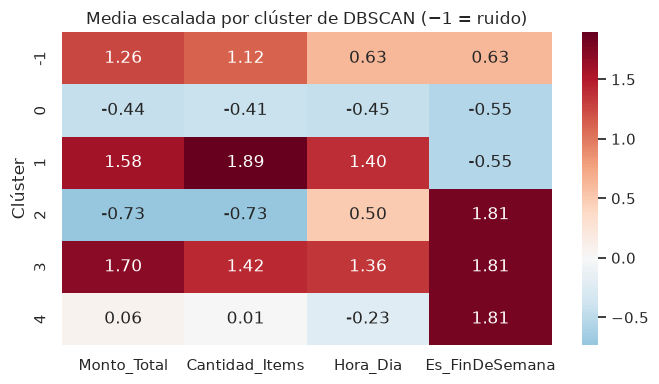

In [17]:
# Perfil escalado de cada clúster de DBSCAN (equivalente al mapa de calor de centroides de K-means)
medias = pd.DataFrame(X_scaled, columns=FEATURES).groupby(lab).mean()
plt.figure(figsize=(7, 4))
sns.heatmap(medias, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Media escalada por clúster de DBSCAN (−1 = ruido)"); plt.ylabel("Clúster")
plt.tight_layout(); plt.savefig("fig_heatmap_dbscan.png", dpi=150); plt.show()

## 10. Comparación con K-means

In [18]:
km_lab = kmeans.labels_
met_km = {"clusters": 6, "ruido": 0, "ruido_%": 0.0,
          "silueta": silhouette_score(X_scaled, km_lab),
          "davies_bouldin": davies_bouldin_score(X_scaled, km_lab),
          "calinski_harabasz": calinski_harabasz_score(X_scaled, km_lab),
          "silueta_con_ruido": silhouette_score(X_scaled, km_lab)}
comparacion = pd.DataFrame({"K-means": met_km, "DBSCAN": met_db})
comparacion

,K-means,DBSCAN
clusters,6.000,5.000
ruido,0.000,112.000
ruido_%,0.000,7.537
silueta,0.562,0.535
davies_bouldin,0.692,0.589
calinski_harabasz,2177.835,1086.539
silueta_con_ruido,0.562,0.457


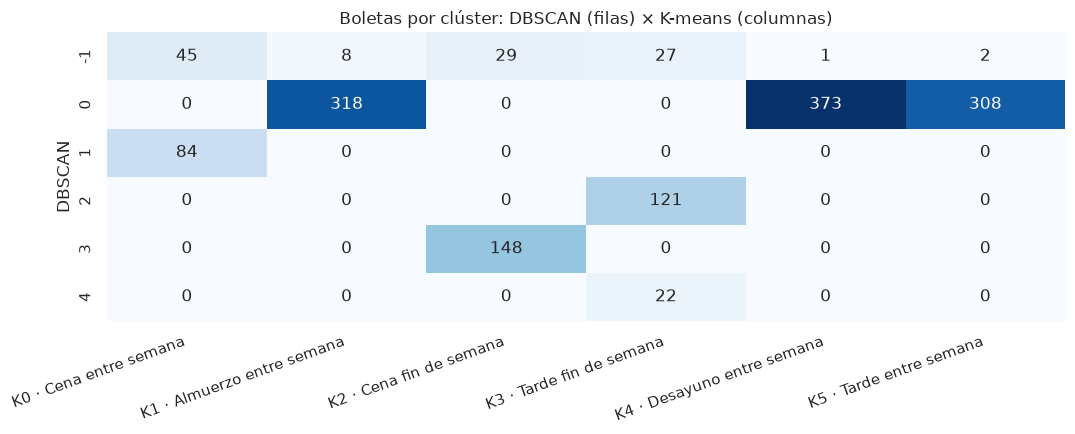

ARI K-means vs DBSCAN (sin ruido): 0.333
ARI K-means vs DBSCAN (ruido como grupo): 0.34


In [19]:
# Tabla cruzada: ¿cómo se reparten los clústeres de K-means en DBSCAN?
tabla = pd.crosstab(df["Cluster_DBSCAN"], df["Cluster_KMeans"].map(lambda c: f"K{c} · {NOMBRES_KM[c]}"))
plt.figure(figsize=(11, 4.5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Boletas por clúster: DBSCAN (filas) × K-means (columnas)"); plt.xlabel(""); plt.ylabel("DBSCAN")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.savefig("fig_tabla_cruzada.png", dpi=150); plt.show()

print("ARI K-means vs DBSCAN (sin ruido):", round(adjusted_rand_score(km_lab[m], lab[m]), 3))
print("ARI K-means vs DBSCAN (ruido como grupo):", round(adjusted_rand_score(km_lab, lab), 3))

### Asignar una venta nueva con cada modelo
K-means tiene `predict`: se elige el centroide más cercano. DBSCAN **no** tiene `predict`: una venta nueva
se asigna al clúster del **punto núcleo más cercano** si está a menos de `eps`; si no, es ruido.

In [20]:
nucleos = X_scaled[dbscan.core_sample_indices_]
etiq_nucleos = dbscan.labels_[dbscan.core_sample_indices_]
nn_nucleos = NearestNeighbors(n_neighbors=1).fit(nucleos)

def predecir_dbscan(X_nuevo_scaled):
    d, i = nn_nucleos.kneighbors(X_nuevo_scaled)
    return np.where(d[:, 0] <= EPS, etiq_nucleos[i[:, 0]], -1)

ventas = pd.DataFrame([[85, 4, 21, 1],    # cena grupal un sábado
                       [16, 2, 8, 0],     # desayuno un martes
                       [12, 1, 16, 1],    # tarde de domingo
                       [30, 3, 13, 1],    # almuerzo de sábado
                       [240, 12, 11, 0]], # pedido grande a media mañana
                      columns=FEATURES)
Xn = scaler.transform(ventas)
ventas["K-means"] = [f"K{c} · {NOMBRES_KM[c]}" for c in kmeans.predict(Xn)]
ventas["DBSCAN"] = predecir_dbscan(Xn)
ventas

,Monto_Total,Cantidad_Items,Hora_Dia,Es_FinDeSemana,K-means,DBSCAN
0,85,4,21,1,K2 · Cena fin de semana,3
1,16,2,8,0,K4 · Desayuno entre semana,0
2,12,1,16,1,K3 · Tarde fin de semana,2
3,30,3,13,1,K3 · Tarde fin de semana,4
4,240,12,11,0,K0 · Cena entre semana,-1


In [21]:
# Coherencia del método de asignación: reasignar las boletas de entrenamiento debe reproducir las etiquetas
re = predecir_dbscan(X_scaled)
print("Coincidencia con las etiquetas de DBSCAN:", round((re == lab).mean() * 100, 1), "%")

Coincidencia con las etiquetas de DBSCAN: 100.0 %


## 11. Modelo elegido para el despliegue: K-means
Se despliega **K-means**. Aunque DBSCAN aporta hallazgos propios (ver el informe), K-means:

* segmenta **todas** las ventas (DBSCAN deja un porcentaje como ruido, sin segmento que mostrar en la app);
* separa los turnos de entre semana (desayuno, almuerzo y tarde), que DBSCAN une en un solo grupo grande;
* tiene grupos de tamaño equilibrado e interpretables como "ticket típico";
* asigna una venta nueva con una sola operación (`predict`), sin guardar todos los puntos núcleo.

La API desplegada en Render (`https://api-cafeteria-4nd9.onrender.com`) carga el modelo K-means (`kmeans_model.pkl`),
el escalador (`scaler.pkl`) y los nombres de los clústeres (`config_modelo.json`) exportados desde el cuaderno de
Google Colab. Como comprobación, se predicen aquí las ventas que se probaron contra la API desplegada (Postman y
la app Android) y se comparan con las respuestas que devolvió el servidor.

In [22]:
def asignar_segmento(monto, items, hora, dia_semana):
    # Misma preparación que en el entrenamiento: Es_FinDeSemana = 1 si dia_semana >= 6
    x = pd.DataFrame([[monto, items, hora, int(dia_semana >= 6)]], columns=FEATURES)
    c = int(kmeans.predict(scaler.transform(x))[0])
    return c, NOMBRES_KM[c]

pruebas_api = pd.DataFrame([
    {"prueba": "Postman", "monto": 220, "items": 8, "hora": 8, "dia_semana": 6, "respuesta_api": 2},
    {"prueba": "App Android", "monto": 40, "items": 2, "hora": 8, "dia_semana": 2, "respuesta_api": 4},
])
pred = pruebas_api.apply(lambda r: asignar_segmento(r.monto, r["items"], r.hora, r.dia_semana), axis=1)
pruebas_api["prediccion_local"] = [c for c, _ in pred]
pruebas_api["perfil"] = [n for _, n in pred]
pruebas_api["coincide"] = pruebas_api["prediccion_local"] == pruebas_api["respuesta_api"]
pruebas_api

,prueba,monto,items,hora,dia_semana,respuesta_api,prediccion_local,perfil,coincide
0,Postman,220,8,8,6,2,2,Cena fin de semana,True
1,App Android,40,2,8,2,4,4,Desayuno entre semana,True


In [23]:
# La venta de Postman (S/ 220 a las 8 h de un sábado) no se parece a ninguna boleta de entrenamiento:
# K-means la asigna igual al centroide más cercano, mientras que DBSCAN la marca como ruido.
x_postman = scaler.transform(pd.DataFrame([[220, 8, 8, 1]], columns=FEATURES))
d_nucleo, _ = nn_nucleos.kneighbors(x_postman)
print("DBSCAN:", predecir_dbscan(x_postman)[0], "| distancia al núcleo más cercano:", round(d_nucleo[0, 0], 2), "| eps:", EPS)
print("Mayor monto de un desayuno de fin de semana en los datos: S/",
      df.loc[(df["Es_FinDeSemana"] == 1) & (df["Hora_Dia"] <= 10), "Monto_Total"].max())

DBSCAN: -1 | distancia al núcleo más cercano: 4.73 | eps: 0.5
Mayor monto de un desayuno de fin de semana en los datos: S/ 67.7


In [24]:
df.to_csv("ventas_cafeteria_dos_modelos.csv", index=False)